In [80]:
# import packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import textwrap

In [2]:
# read csv file
# from https://open.toronto.ca/dataset/seniors-survey-2017/
# download the xlsx file and exported the csv
df = pd.read_csv('seniors-survey-2017-results.csv')

In [3]:
# Rename specific columns and modify the DataFrame in place
df.rename(columns={'1. In the past 3 months, how often did you participate in physical activities like walking?': 'partcipation_physical_activities', 
                   '2. Are you aware that Toronto Public Health and your Local Health Integration Network offer free exercise and falls prevention programs?': 'awareness_free_exercise_and_fall_prevention_programmes',
                   '3. In the past year have you visited a library branch, accessed the library online or contacted the library by telephone?': 'accessed_library_service',
                   '4. How often do you use the internet?': 'internet_usage',
                   '5. During the past 3 months, how often did you participate in volunteer or charity work?':'volunteer',
                   '6. To get around Toronto, what modes of transportation do you use frequently?  [Walk]':'mode_transportation_walk',
                   '7. Do you frequently use the TTC?':'frequently_use_ttc',
                   'If you answered no to above question, why not?  [I have access to other transportation services that serve me well]': 'no__ttc_access_other_transportation',
                   'If you answered no to above question, why not?  [It is quicker to drive (it takes less time)]': 'no__ttc_quicker_to_drive',
                   'If you answered no to above question, why not?  [I prefer to drive]': 'no__ttc_prefer_to_drive',
                   'If you answered no to above question, why not?  [TTC is not affordable for me]': 'no__ttc_not_affordable',
                   'If you answered no to above question, why not?  [The nearest TTC stop/station is too far away]': 'no__ttc_too_far_away',
                   'If you answered no to above question, why not?  [The nearest TTC stop/station is not accessible]': 'no__ttc_station_not_accessible',
                   'If you answered no to above question, why not?  [TTC vehicles are not accessible for me]': 'no__ttc_vehicles_not_accessible',
                   'If you answered no to above question, why not?  [The TTC is too crowded]': 'no__ttc_crowded',
                   'If you answered no to above question, why not?  [TTC announcements are hard to hear]': 'no__ttc_announcement_hard_to_hear',
                   "If you answered no to above question, why not?  [I don't feel safe using the TTC]": 'no__ttc_do_not_feel_safe',
                   '8. In the past year, have you had to delay home repairs or modifications because they were unaffordable? [A major home repair such as a new roof, furnace, or plumbing or electrical problems?]': 'unaffordable_major',
                   '8. In the past year, have you had to delay home repairs or modifications because they were unaffordable? [Modifications to make your home more accessible, for example, converting a bathtub to a shower, a ramp, grab bars in the bathroom, or better lighting to improve visibility?]': 'unaffordable_accessibility',
                   '8. In the past year, have you had to delay home repairs or modifications because they were unaffordable? [No or not applicable]': 'unaffordable_no',
                   '9. In the last year, have you had difficulty paying your rent, mortgage, Hydro bill, or other housing costs? For example, have you had to go without groceries to pay for rent or other monthly housing expenses?':'difficulty_paying_bills',
                   '11. What are your top three concerns related to older persons in Toronto? [Accessibility]': 'concerns_related_to_older_persons_accessibility',
                   '11. What are your top three concerns related to older persons in Toronto? [Civic Engagement]': 'concerns_related_to_civic_engagement',
                   '11. What are your top three concerns related to older persons in Toronto? [Communication and Information]': 'concerns_related_to_communication_and_info',
                   '11. What are your top three concerns related to older persons in Toronto? [Food Access]': 'concerns_related_to_older_persons_food_access',
                   '11. What are your top three concerns related to older persons in Toronto? [Health Care and Home Care Services]':'concerns_related_to_older_persons_care_service',
                   '11. What are your top three concerns related to older persons in Toronto? [Housing Affordability and Availability]': 'concerns_related_to_older_persons_housing',
                   '11. What are your top three concerns related to older persons in Toronto? [Income and Employment]':'concerns_related_to_older_persons_employment',
                   '11. What are your top three concerns related to older persons in Toronto? [Recreation and Community Services Including Libraries]':'concerns_related_to_older_persons_recreation',
                   '11. What are your top three concerns related to older persons in Toronto? [Respect and Social Inclusion]': 'concerns_related_to_older_persons_respect_inclusion',
                   '11. What are your top three concerns related to older persons in Toronto? [Safety and Security]':'concerns_related_to_older_persons_security',
                   '11. What are your top three concerns related to older persons in Toronto? [Transportation Issues (for example, pedestrain safety, sidewalks, TTC)]':'concerns_related_to_older_persons_respect_transportation',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [City of Toronto website www.toronto.ca]': 'learn_about_services__website',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Internet search engine, for example Google]': 'learn_about_services__internetsearch',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [By calling 311 (information on city services, for example garbage collection)]': 'learn_about_services__311',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [By calling 211 (information on provincial health and community services)]': 'learn_about_services__211',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Local Ward Councillor]': 'learn_about_services__local_ward_councillor',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Services for Seniors in Toronto (Service Directory)]': 'learn_about_services__service_directory',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Posters, brochures, pamphlets]': 'learn_about_services__posters',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Community Agencies, Doctors, Nurses, or Social Workers]': 'learn_about_services__agencies',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Faith group, for example, church, Mosque, Temple]': 'learn_about_services__faith_group',
                   '12. Have you ever used any of the following to learn about City of Toronto/municipal government services for older persons? [Word of mouth]': 'learn_about_services__word_mouth',
                   '13. Do you have people in your life who you can call on for help if you need it?':'has_people_can_call_for_help',
                   '14. What are the first three characters of your postal code?': 'postal_code_first_part',
                   '15. What is your current employment status?': 'employment_status',
                   '16. What is your sex/gender?': 'gender',
                   '17. Can you understand, speak or read English? [None of the above]': 'english__do_not_understand',
                   '19. Which age category do you belong to?':'age_category',
                   #'':'',
                   }, 
                   
          inplace=True) 

df.columns

Index(['partcipation_physical_activities',
       'awareness_free_exercise_and_fall_prevention_programmes',
       'accessed_library_service', 'internet_usage', 'volunteer',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [TTC (bus, subway, or streetcar)]',
       'mode_transportation_walk',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Drive]',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Cycle]',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Taxi or Uber]',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Community Transportation Program, for example Toronto Ride or iRIDE]',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Wheel-Trans]',
       '6. To get around Toronto, what modes of transportation do you use frequently?  [Rides from family, f

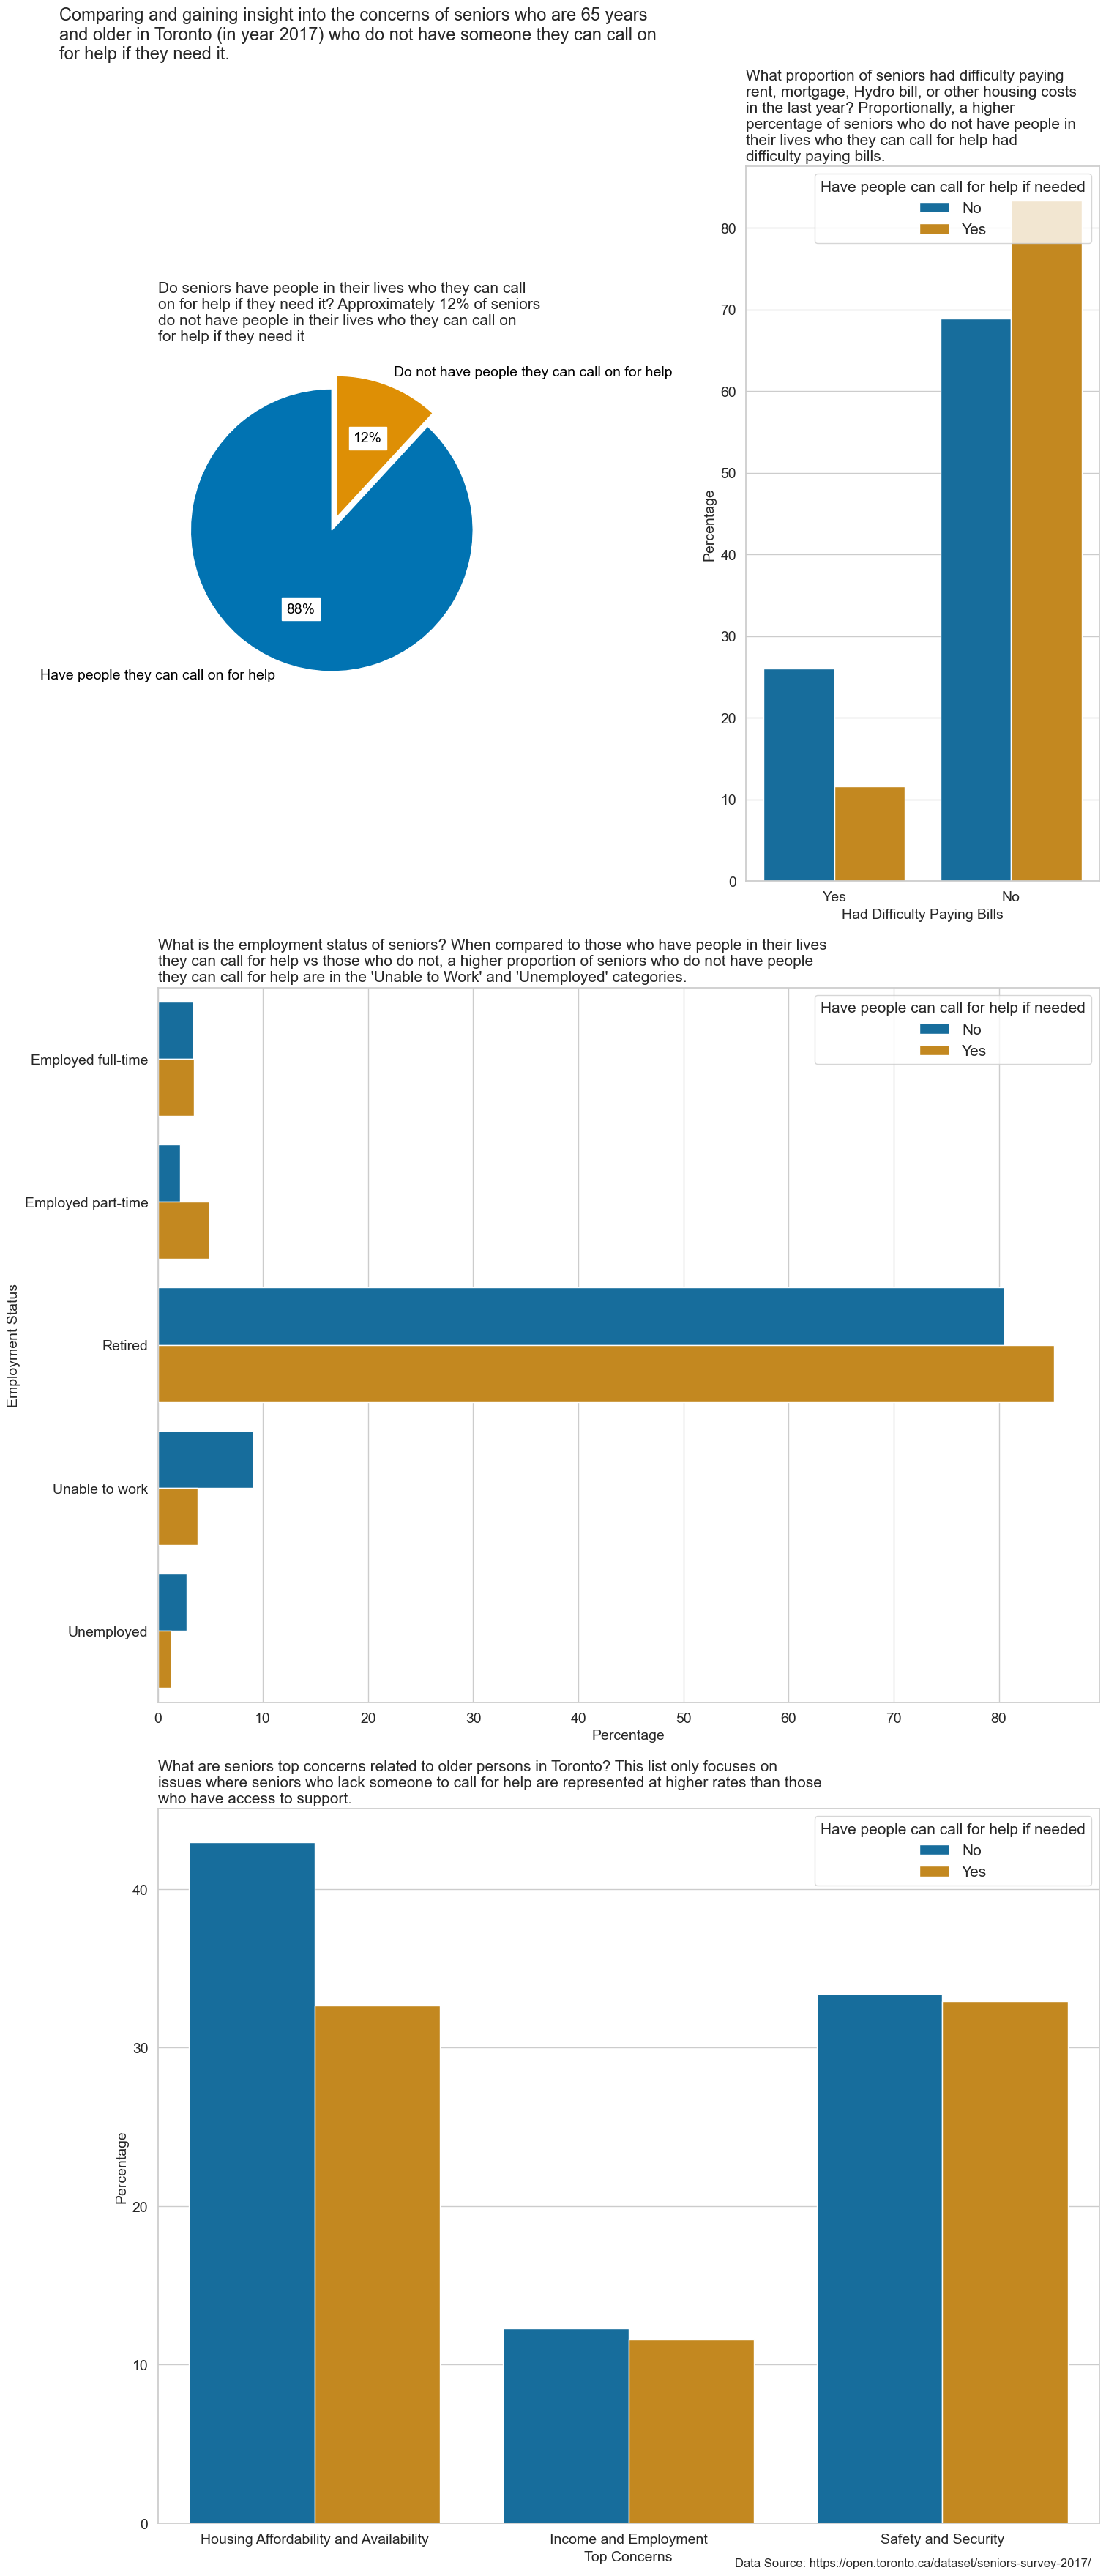

In [108]:
# This may not be needed but adding just in case
np.random.seed(613)

# Filter dataset to only include rrspondents who are 65 years and older
df_over_65 = df[(df['age_category'] == '65-69 years') | (df['age_category'] == '70-74 years') | (df['age_category'] == '75-79 years') | (df['age_category'] == '80-84 years')  | (df['age_category'] == '85 years or older')]

# filter dataset - only include respondents who have people they could call for help - has_people_can_call_for_help
df_has_people_can_call_for_help = df_over_65[df_over_65['has_people_can_call_for_help'] == 'Yes']
# filter dataset - only include respondents who do not have people they could call for help - has_people_can_call_for_help
df_not_has_people_can_call_for_help = df_over_65[df_over_65['has_people_can_call_for_help'] == 'No']
 

# Chart 1
# Graph comparing number of respondednt who has people who they can call for help vs who do not have people they can call for help
slides = [df_has_people_can_call_for_help.shape[0], df_not_has_people_can_call_for_help.shape[0]]
labels = ["Have people they can call on for help", "Do not have people they can call on for help"]

# Chart 2
# difficulty paying bills
# Graph comparing number of respondednt who have difficulty paying bills - comparing those who have people who they can call for help vs who do not have people they can call for help
no_group_difficulty_paying_bills = (df_not_has_people_can_call_for_help.groupby(['difficulty_paying_bills'], dropna = False).size() / df_not_has_people_can_call_for_help.shape[0]) * 100

yes_group_difficulty_paying_bills = (df_has_people_can_call_for_help.groupby(['difficulty_paying_bills'], dropna = False).size() / df_has_people_can_call_for_help.shape[0]) * 100


df_data_difficulty_paying_bills  =  pd.DataFrame({
    'Had Difficulty Paying Bills': ['Yes', 'Yes', 'No', 'No'],
    'Percentage': [no_group_difficulty_paying_bills['Yes'], yes_group_difficulty_paying_bills['Yes'], no_group_difficulty_paying_bills['No'], yes_group_difficulty_paying_bills['No']],
    'Have people can call for help if needed': ['No', 'Yes', 'No', 'Yes']
})

         

# Chart 3
# employment_status
# graph comparing employment status for people who have people they can count on vs those who do not
no_group_employment_status = (df_not_has_people_can_call_for_help.groupby(['employment_status'], dropna = False).size() / df_not_has_people_can_call_for_help.shape[0]) * 100

yes_group_employment_status = (df_has_people_can_call_for_help.groupby(['employment_status'], dropna = False).size() / df_has_people_can_call_for_help.shape[0]) * 100

df_data_employment_status  = pd.DataFrame({
    'Employment Status': ['Employed full-time', 'Employed full-time', 'Employed part-time', 'Employed part-time', 'Retired', 'Retired', 'Unable to work', 'Unable to work', 'Unemployed', 'Unemployed'],
    'Percentage':[no_group_employment_status['Employed full-time'], yes_group_employment_status['Employed full-time'], no_group_employment_status['Employed part-time'], yes_group_employment_status['Employed part-time'], no_group_employment_status['Retired'], yes_group_employment_status['Retired'], no_group_employment_status['Unable to work for health or other reasons'], yes_group_employment_status['Unable to work for health or other reasons'],  no_group_employment_status['Unemployed, looking for work'], yes_group_employment_status['Unemployed, looking for work']],
    'Have people can call for help if needed':['No', 'Yes','No', 'Yes','No', 'Yes','No', 'Yes','No', 'Yes',],
})

# Chart 4
# volunteer
no_group_volunteer = (df_not_has_people_can_call_for_help.groupby(['volunteer'], dropna = False).size() / df_not_has_people_can_call_for_help.shape[0]) * 100
yes_group_volunteer = (df_has_people_can_call_for_help.groupby(['volunteer'], dropna = False).size() / df_has_people_can_call_for_help.shape[0]) * 100

df_data_volunteer  = pd.DataFrame({
    'How often': ['At least once a day', 'At least once a day', 'At least a few times a week', 'At least a few times a week', 'At least once a week', 'At least once a week', 'At least once a month', 'At least once a month', 'Never', 'Never'],
    'Percentage':[no_group_volunteer['At least once a day'], yes_group_volunteer['At least once a day'], no_group_volunteer['At least a few times a week'], yes_group_volunteer['At least a few times a week'], no_group_volunteer['At least once a week'], yes_group_volunteer['At least once a week'], no_group_volunteer['At least once a month'], yes_group_volunteer['At least once a month'],  no_group_volunteer['Never'], yes_group_volunteer['Never']],
    'Have people can call for help if needed':['No', 'Yes','No', 'Yes','No', 'Yes','No', 'Yes','No', 'Yes',],
})

# Chart 5
concern_list = ['concerns_related_to_older_persons_housing', 'concerns_related_to_older_persons_employment', 'concerns_related_to_older_persons_security']
concern_list_desc = ['Housing Affordability and Availability', 'Income and Employment', 'Safety and Security']
category_list = []
percentage_values = []
have_people_values = []

i = 0
for concern in concern_list:
    no_group = (df_not_has_people_can_call_for_help.groupby([concern], dropna = False).size() / df_not_has_people_can_call_for_help.shape[0]) * 100
    yes_group = (df_has_people_can_call_for_help.groupby([concern], dropna = False).size() / df_has_people_can_call_for_help.shape[0]) * 100
    
    category_list.append(concern_list_desc[i])
    category_list.append(concern_list_desc[i])

    percentage_values.append(no_group[1.0])
    percentage_values.append(yes_group[1.0])

    have_people_values.append('No')
    have_people_values.append('Yes')
    i += 1


data = {
    'Top Concerns': category_list,
    'Percentage': percentage_values,
    'Have people can call for help if needed': have_people_values
}


df_data_concerns = pd.DataFrame(data)


# Chart 6
resource_list = ['learn_about_services__website', 'learn_about_services__internetsearch', 'learn_about_services__311', 'learn_about_services__word_mouth']
resource_list_desc = ['City of Toronto website', 'Internet Search Engine', 'Calling 311', 'Word of Mouth']

category_list = []
percentage_values = []
have_people_values = []

i = 0
for resource in resource_list:
    no_group = (df_not_has_people_can_call_for_help.groupby([resource], dropna = False).size() / df_not_has_people_can_call_for_help.shape[0]) * 100

    category_list.append(resource_list_desc[i])

    percentage_values.append(no_group[1.0])

    have_people_values.append('No')
    i += 1


data = {
    'Resources used to learn about City of Toronto/municipal government services': category_list,
    'Percentage': percentage_values,
    'Have people can call for help if needed': have_people_values
}

df_data_resources = pd.DataFrame(data)

# Render Charts
# 1. Create a figure and define the GridSpec
# define figure
fig = plt.figure(figsize=(15, 35),  constrained_layout=True)
#plt.figtext(0.5, 0.95, '', ha='center', fontsize=14, fontweight='bold')

# setting
font_title = {'size':15}
font1 = {'size':14}

# Add main title
long_title = "Comparing and gaining insight into the concerns of seniors who are 65 years and older in Toronto (in year 2017) who do not have someone they can call on for help if they need it.  \n"
wrapped_title = textwrap.fill(long_title, width=77) # Adjust width as needed
plt.suptitle(wrapped_title, x=0.05, horizontalalignment='left',  fontsize=17)

gs = fig.add_gridspec(3, 2) # Defines a 5 rows, 2 column grid

# 2. Define the axes using the GridSpec
# Ax 0: Spans row 0, and column 0
ax0 = fig.add_subplot(gs[0, 0])
# Ax 1: Spans row 0, column 1
ax1 = fig.add_subplot(gs[0, 1])
# Ax 2: Spans row 1
ax2 = fig.add_subplot(gs[1, :])
# Ax 3: Spans row 2
ax3 = fig.add_subplot(gs[2, :])


# 2. Apply Seaborn color palette - colorblind seems accessibility friendly
sns.set_theme(palette="colorblind") # Use a Seaborn color palette
sns.set_style("whitegrid")

# Chart 1
# spacing between pie chart
explode = (0.05, 0.05) 

patches =  ax0.pie(slides, labels=labels, autopct='%.0f%%', startangle=90, explode=explode, textprops={'backgroundcolor': 'white', 'color': 'black', 'fontsize': 14})[0]

long_title = "Do seniors have people in their lives who they can call on for help if they need it? Approximately 12% of seniors do not have people in their lives who they can call on for help if they need it"
# Wrap the title text
wrapped_title = textwrap.fill(long_title, width=57) # Adjust width as needed


ax0.set_title(wrapped_title, loc='left', fontdict=font_title)


# Chart 2
# Plot 
sns.barplot(data=df_data_difficulty_paying_bills, x='Had Difficulty Paying Bills', y='Percentage', hue='Have people can call for help if needed', ax=ax1)
long_title = "What proportion of seniors had difficulty paying rent, mortgage, Hydro bill, or other housing costs in the last year? Proportionally, a higher percentage of seniors who do not have people in their lives who they can call for help had difficulty paying bills."
# Wrap the title text
wrapped_title = textwrap.fill(long_title, width=50) # Adjust width as needed
ax1.set_title(wrapped_title , loc='left', fontdict=font_title)
#ax1.set_xlabel('')

# Chart 3
# plot
sns.barplot(data=df_data_employment_status, x='Percentage', y='Employment Status', hue='Have people can call for help if needed', legend=True, ax=ax2)
long_title = "What is the employment status of seniors? When compared to those who have people in their lives they can call for help vs those who do not, a higher proportion of seniors who do not have people they can call for help are in the 'Unable to Work' and 'Unemployed' categories."
# Wrap the title text
wrapped_title = textwrap.fill(long_title, width=97) # Adjust width as needed
ax2.set_title(wrapped_title, loc='left', fontdict=font_title)




# Chart 4
# plot
sns.barplot(data=df_data_concerns, y='Percentage', x='Top Concerns', hue='Have people can call for help if needed', legend=True, ax=ax3)
long_title = "What are seniors top concerns related to older persons in Toronto? This list only focuses on issues where seniors who lack someone to call for help are represented at higher rates than those who have access to support. "
wrapped_title = textwrap.fill(long_title, width=97) # Adjust width as needed
ax3.set_title(wrapped_title, loc='left', fontdict=font_title)

# customizing legends

ax1.legend(title='Have people can call for help if needed', fontsize=15, title_fontsize=15)
ax2.legend(title='Have people can call for help if needed', fontsize=15, title_fontsize=15)
ax3.legend(title='Have people can call for help if needed', fontsize=15, title_fontsize=15)


# setting x and y labels

ax1.set_xlabel('Had Difficulty Paying Bills', fontdict=font1)
ax1.set_ylabel('Percentage', fontdict=font1)

ax2.set_xlabel('Percentage', fontdict=font1)
ax2.set_ylabel('Employment Status', fontdict=font1)


ax3.set_xlabel('Top Concerns', fontdict=font1)
ax3.set_ylabel('Percentage', fontdict=font1)


ax0.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='major', labelsize=14)



# add data source
plt.figtext(0.99, 0.00, "Data Source: https://open.toronto.ca/dataset/seniors-survey-2017/", horizontalalignment='right', fontsize=12)
#plt.tight_layout()
plt.show()



